# FIRAS Limits on Photon Injection — Chluba (2015) Fig. 9

Reproduce Fig. 9 from [Chluba (2015)](https://arxiv.org/abs/1506.06582): COBE/FIRAS upper limits
on $\Delta N_\gamma / N_\gamma$ as a function of injection frequency $x_i = h\nu_i/(kT)$
at three injection redshifts.

**Method**: For each $(x_i, z_h)$, compute $\mu$ and $y$ per unit $\Delta N/N$ from
both the **full PDE solver** and the **Green's function**. Then invert the FIRAS 68% CL limits
$|\mu| < 4.5\times10^{-5}$, $|y| < 7.5\times10^{-6}$ to get the maximum allowed $\Delta N/N$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from spectroxide import (
    ALPHA_RHO, X_BALANCED, KAPPA_C, G2_PLANCK, G3_PLANCK,
    photon_survival_probability,
    greens_function_photon,
    mu_from_photon_injection,
    mu_shape, y_shape, temperature_shift_shape, g_bb,
    j_bb_star, j_mu, j_y,
    apply_style,
)

from spectroxide.solver import solve

apply_style()

# FIRAS 68% CL (1-sigma) limits — matches Chluba (2015) Fig. 9 convention
MU_FIRAS = 4.5e-5
Y_FIRAS = 7.5e-6

print(f'alpha_rho = {ALPHA_RHO:.4f}')
print(f'x_0 (balanced) = {X_BALANCED:.3f}')
print(f'kappa_c = {KAPPA_C}')

alpha_rho = 0.3702
x_0 (balanced) = 3.602
kappa_c = 2.1419


## Helper functions

In [2]:
def default_sigma_x(x_inj):
    return x_inj * 0.05

def run_pde_photon(x_inj, z_h, delta_n_over_n=1e-5, sigma_x=None,
                   z_end=500, n_points=None, timeout=600):
    """Run PDE solver for monochromatic photon injection.
    
    Uses production-quality defaults (4000 pts, production grid, dtau=1).
    """
    if sigma_x is None:
        sigma_x = default_sigma_x(x_inj)
    sweep_kwargs = dict(
        injection={
            'type': 'monochromatic_photon',
            'x_inj': x_inj,
            'delta_n_over_n': delta_n_over_n,
            'z_h': z_h,
            'sigma_x': sigma_x,
        },
        z_start=z_h + 7 * max(z_h * 0.04, 100),
        z_end=z_end,
        number_conserving=False,
        nc_z_min=0,
        timeout=timeout,
    )
    if n_points is not None:
        sweep_kwargs['n_points'] = n_points
    result = solve(**sweep_kwargs)
    return np.asarray(result.x), np.asarray(result.delta_n), result.mu, result.y

def y_from_photon_injection_gf(x_inj, z_h, delta_n_over_n):
    """Compute y from photon injection using the GF spectrum decomposition.
    
    Project the GF spectrum onto Y_SZ(x) via least-squares.
    """
    x_grid = np.linspace(0.5, 25, 2000)
    gf_spec = greens_function_photon(x_grid, x_inj, z_h) * delta_n_over_n
    
    # Least-squares: fit y*Y_SZ(x) + mu*M(x) + alpha*G_bb(x) to gf_spec
    M = mu_shape(x_grid)
    Y = y_shape(x_grid)
    G = g_bb(x_grid)
    
    A = np.column_stack([M, Y, G])
    coeffs, _, _, _ = np.linalg.lstsq(A, gf_spec, rcond=None)
    return coeffs[1]  # y coefficient

print('Helpers defined (using PRODUCTION quality defaults).')

Helpers defined (using PRODUCTION quality defaults).


## GF analytical limits (fast)

Compute $\mu$ and $y$ per unit $\Delta N/N$ from the Green's function for a dense grid of $x_i$ values.

In [3]:
x_i_dense = np.concatenate([
    np.linspace(0.1, 1.0, 20),
    np.linspace(1.0, 15.0, 100)[1:]
])

z_values = [2e6, 1e6, 3e5]
z_labels = [r'$z = 2\times10^6$', r'$z = 10^6$', r'$z = 3\times10^5$']
z_colors = ['C0', 'C1', 'C2']

gf_results = {}

for z_h in z_values:
    mu_arr = np.array([mu_from_photon_injection(x, z_h, 1.0) for x in x_i_dense])
    y_arr = np.array([y_from_photon_injection_gf(x, z_h, 1.0) for x in x_i_dense])
    
    # FIRAS limits: dn/n_max = min(mu_firas/|mu|, y_firas/|y|)
    dn_max_mu = np.where(np.abs(mu_arr) > 1e-20, MU_FIRAS / np.abs(mu_arr), np.inf)
    dn_max_y = np.where(np.abs(y_arr) > 1e-20, Y_FIRAS / np.abs(y_arr), np.inf)
    dn_max = np.minimum(dn_max_mu, dn_max_y)
    
    gf_results[z_h] = {
        'x_i': x_i_dense,
        'mu': mu_arr,
        'y': y_arr,
        'dn_max': dn_max,
        'dn_max_mu': dn_max_mu,
        'dn_max_y': dn_max_y,
    }
    print(f'z = {z_h:.0e}: mu range [{mu_arr.min():.3e}, {mu_arr.max():.3e}], '
          f'y range [{y_arr.min():.3e}, {y_arr.max():.3e}]')

print('GF limits computed.')

z = 2e+06: mu range [-5.712e-01, 2.003e+00], y range [-9.437e-16, 1.110e-15]
z = 1e+06: mu range [-1.396e+00, 4.809e+00], y range [-1.790e-15, 5.967e-15]
z = 3e+05: mu range [-1.691e+00, 5.756e+00], y range [-2.467e-07, 4.274e-15]
GF limits computed.


/tmp/ipykernel_7632/896056787.py:18: RuntimeWarning: divide by zero encountered in divide
  dn_max_y = np.where(np.abs(y_arr) > 1e-20, Y_FIRAS / np.abs(y_arr), np.inf)


## PDE solver sweep

Run the full PDE solver at selected $x_i$ values for each redshift. This takes ~10-30 min.

In [4]:
# PDE x_i values: sparser than GF but covering key features
x_i_pde = np.array([0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3.0, 3.3, 3.5, 3.8, 4.0,
                     4.5, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 15.0])

dn_over_n = 1e-5  # Fiducial injection amplitude

pde_results = {}
t0_total = time.time()

for z_h in z_values:
    mu_list = []
    y_list = []
    t0 = time.time()
    
    for i, x_i in enumerate(x_i_pde):
        print(f'  z={z_h:.0e}, x_i={x_i:5.2f} ({i+1}/{len(x_i_pde)}) ...', end='', flush=True)
        try:
            _, _, mu, y = run_pde_photon(x_i, z_h, delta_n_over_n=dn_over_n)
            mu_list.append(mu)
            y_list.append(y)
            print(f' mu={mu:.3e}, y={y:.3e}')
        except Exception as e:
            print(f' FAILED: {e}')
            mu_list.append(np.nan)
            y_list.append(np.nan)
    
    mu_arr = np.array(mu_list)
    y_arr = np.array(y_list)
    
    # Normalize to per-unit DN/N
    mu_per_unit = mu_arr / dn_over_n
    y_per_unit = y_arr / dn_over_n
    
    # FIRAS limits
    dn_max_mu = np.where(np.abs(mu_per_unit) > 1e-20, MU_FIRAS / np.abs(mu_per_unit), np.inf)
    dn_max_y = np.where(np.abs(y_per_unit) > 1e-20, Y_FIRAS / np.abs(y_per_unit), np.inf)
    dn_max = np.minimum(dn_max_mu, dn_max_y)
    
    pde_results[z_h] = {
        'x_i': x_i_pde,
        'mu': mu_per_unit,
        'y': y_per_unit,
        'dn_max': dn_max,
        'dn_max_mu': dn_max_mu,
        'dn_max_y': dn_max_y,
    }
    
    dt = time.time() - t0
    print(f'z = {z_h:.0e} done in {dt:.0f}s')
    print()

print(f'Total PDE time: {time.time() - t0_total:.0f}s')

  z=2e+06, x_i= 0.30 (1/20) ... mu=-6.050e-06, y=-6.733e-10
  z=2e+06, x_i= 0.50 (2/20) ... mu=-5.710e-06, y=-6.436e-10
  z=2e+06, x_i= 0.70 (3/20) ... mu=-5.336e-06, y=-6.102e-10
  z=2e+06, x_i= 1.00 (4/20) ... mu=-4.808e-06, y=-8.271e-10
  z=2e+06, x_i= 1.50 (5/20) ... mu=-3.919e-06, y=-5.626e-10
  z=2e+06, x_i= 2.00 (6/20) ... mu=-3.023e-06, y=-3.149e-10
  z=2e+06, x_i= 2.50 (7/20) ... mu=-2.118e-06, y=-2.159e-10
  z=2e+06, x_i= 3.00 (8/20) ... mu=-1.206e-06, y=-1.272e-10
  z=2e+06, x_i= 3.30 (9/20) ... mu=-6.559e-07, y=-7.143e-11
  z=2e+06, x_i= 3.50 (10/20) ... mu=-2.884e-07, y=-3.332e-11
  z=2e+06, x_i= 3.80 (11/20) ... mu=2.637e-07, y=2.513e-11
  z=2e+06, x_i= 4.00 (12/20) ... mu=6.320e-07, y=6.431e-11
  z=2e+06, x_i= 4.50 (13/20) ... mu=1.552e-06, y=1.636e-10
  z=2e+06, x_i= 5.00 (14/20) ... mu=2.486e-06, y=2.642e-10
  z=2e+06, x_i= 6.00 (15/20) ... mu=4.353e-06, y=4.645e-10
  z=2e+06, x_i= 7.00 (16/20) ... mu=6.212e-06, y=6.627e-10
  z=2e+06, x_i= 8.00 (17/20) ... mu=8.068e-06

## Figure 9: FIRAS limits on $\Delta N_\gamma / N_\gamma$

/tmp/ipykernel_7632/1501608316.py:24: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 15)


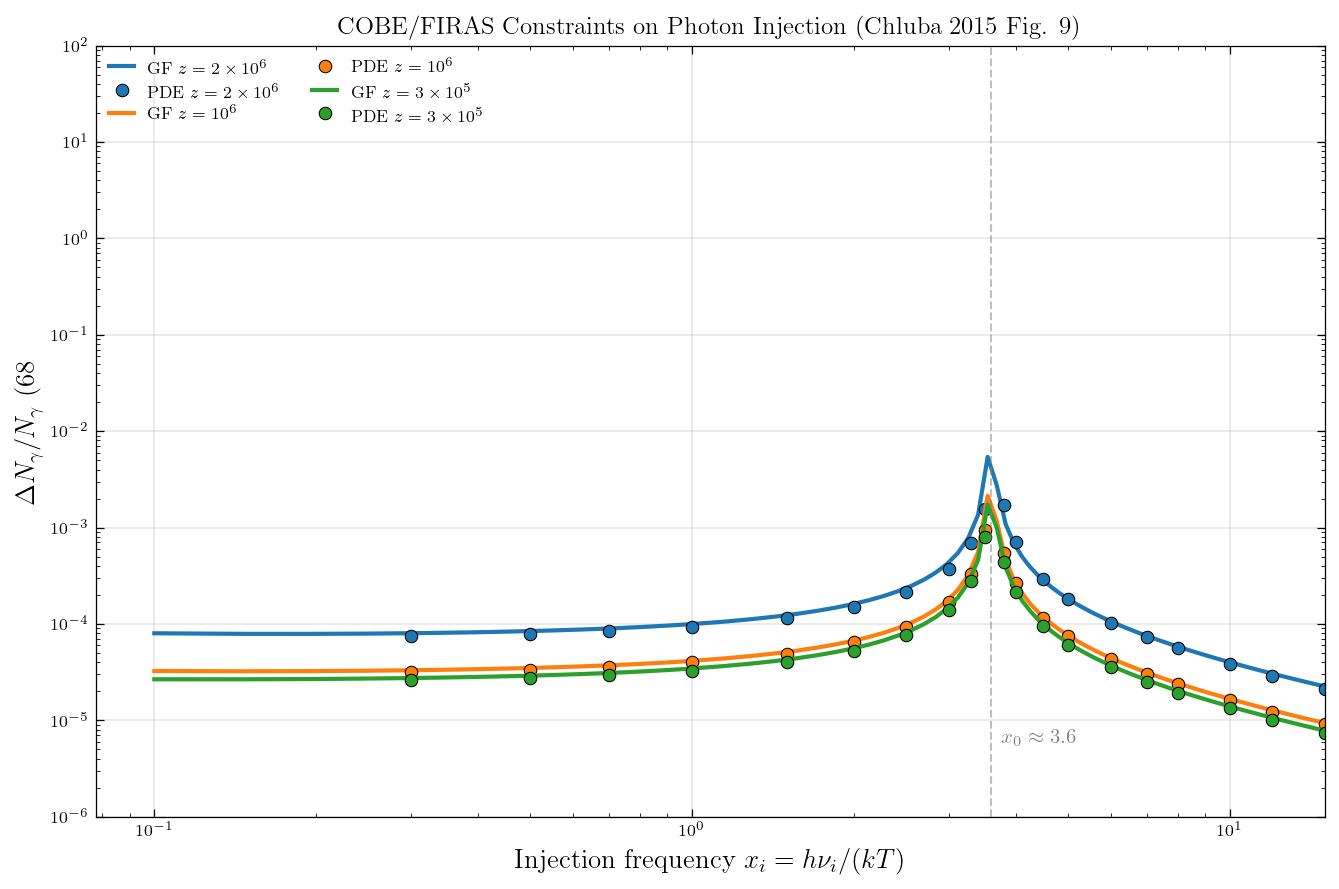

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

for z_h, label, color in zip(z_values, z_labels, z_colors):
    gf = gf_results[z_h]
    pde = pde_results[z_h]
    
    # GF: solid line
    ax.semilogy(gf['x_i'], gf['dn_max'], '-', color=color, lw=2, label=f'GF {label}')
    
    # PDE: markers
    valid = np.isfinite(pde['dn_max']) & (pde['dn_max'] < 1e10)
    ax.loglog(pde['x_i'][valid], pde['dn_max'][valid], 'o', color=color,
                ms=6, markeredgecolor='k', markeredgewidth=0.5,
                label=f'PDE {label}')

ax.axvline(X_BALANCED, color='gray', ls='--', alpha=0.5, lw=1)
ax.text(X_BALANCED + 0.15, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-6,
        f'$x_0 \\approx {X_BALANCED:.1f}$', fontsize=10, color='gray', va='bottom')

ax.set_xlabel(r'Injection frequency $x_i = h\nu_i / (kT)$', fontsize=13)
ax.set_ylabel(r'$\Delta N_\gamma / N_\gamma$ (68% CL upper limit)', fontsize=13)
ax.set_title('COBE/FIRAS Constraints on Photon Injection (Chluba 2015 Fig. 9)', fontsize=12)
ax.legend(fontsize=8, ncol=2)
ax.set_xlim(0, 15)
ax.set_ylim(1e-6, 1e2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/firas_photon_injection_limits.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Diagnostic: $\mu$ and $y$ per unit $\Delta N/N$

Compare PDE vs GF for $\mu$ and $y$ individually, to check which constraint dominates.

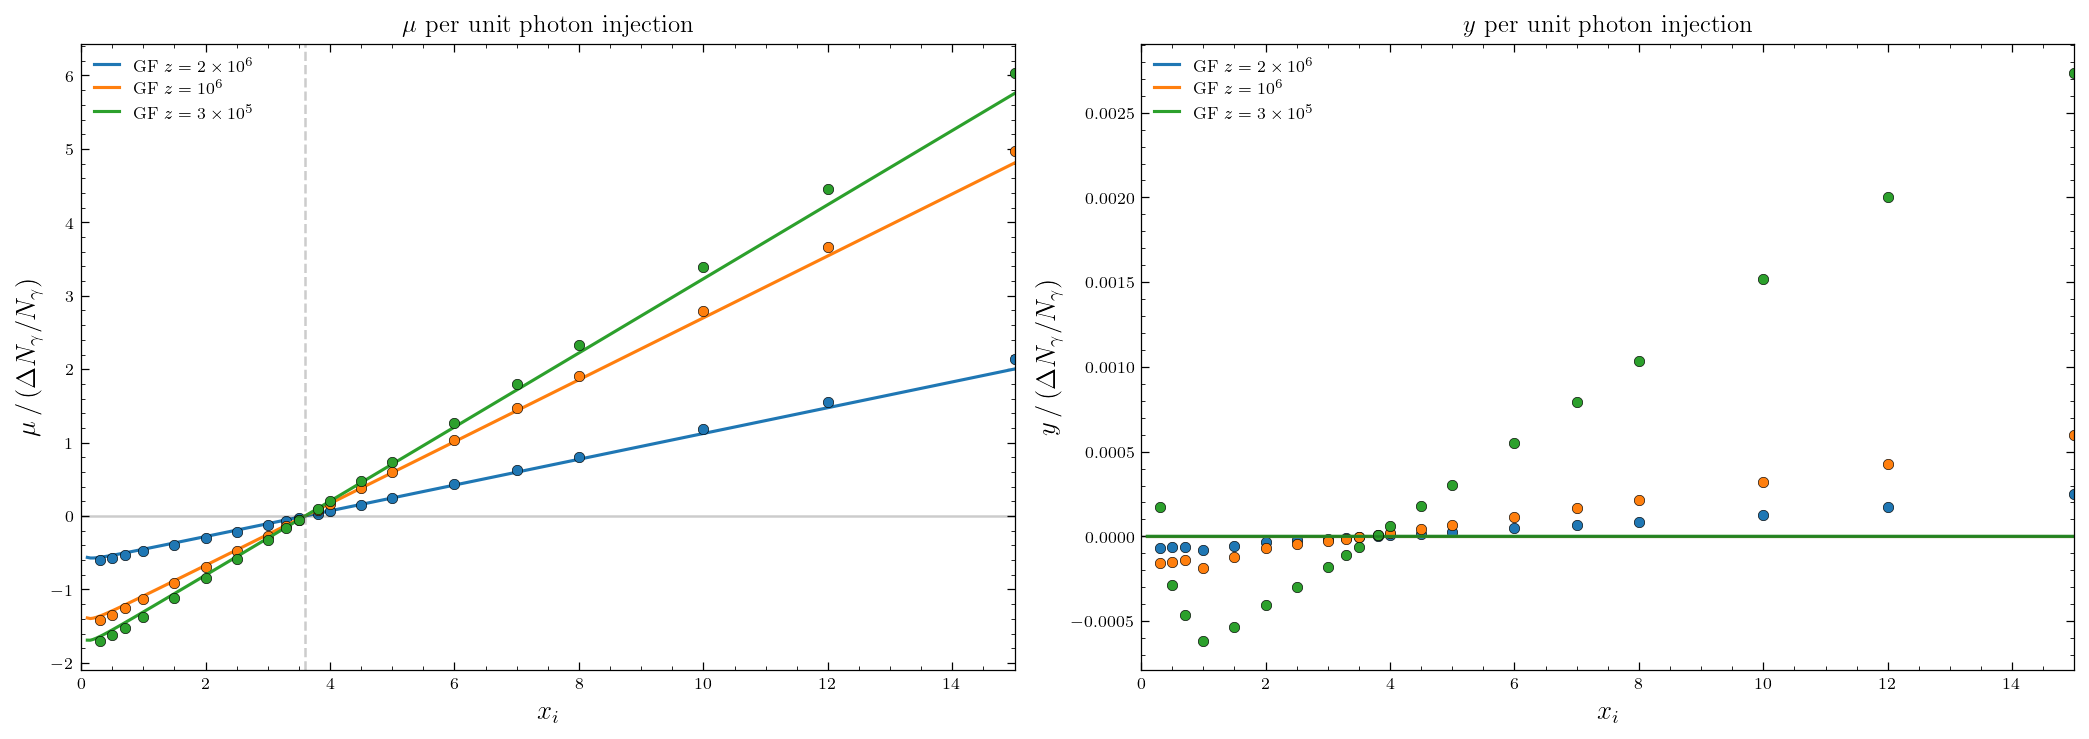

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mu per unit DN/N
ax = axes[0]
for z_h, label, color in zip(z_values, z_labels, z_colors):
    gf = gf_results[z_h]
    pde = pde_results[z_h]
    ax.plot(gf['x_i'], gf['mu'], '-', color=color, lw=1.5, label=f'GF {label}')
    valid = np.isfinite(pde['mu'])
    ax.plot(pde['x_i'][valid], pde['mu'][valid], 'o', color=color, ms=5,
            markeredgecolor='k', markeredgewidth=0.3)

ax.axhline(0, color='k', ls='-', alpha=0.2)
ax.axvline(X_BALANCED, color='gray', ls='--', alpha=0.4)
ax.set_xlabel(r'$x_i$', fontsize=13)
ax.set_ylabel(r'$\mu \, / \, (\Delta N_\gamma / N_\gamma)$', fontsize=13)
ax.set_title(r'$\mu$ per unit photon injection', fontsize=12)
ax.legend(fontsize=8)
ax.set_xlim(0, 15)

# Right: y per unit DN/N
ax = axes[1]
for z_h, label, color in zip(z_values, z_labels, z_colors):
    gf = gf_results[z_h]
    pde = pde_results[z_h]
    ax.plot(gf['x_i'], gf['y'], '-', color=color, lw=1.5, label=f'GF {label}')
    valid = np.isfinite(pde['y'])
    ax.plot(pde['x_i'][valid], pde['y'][valid], 'o', color=color, ms=5,
            markeredgecolor='k', markeredgewidth=0.3)

ax.axhline(0, color='k', ls='-', alpha=0.2)
ax.set_xlabel(r'$x_i$', fontsize=13)
ax.set_ylabel(r'$y \, / \, (\Delta N_\gamma / N_\gamma)$', fontsize=13)
ax.set_title(r'$y$ per unit photon injection', fontsize=12)
ax.legend(fontsize=8)
ax.set_xlim(0, 15)

plt.tight_layout()
plt.savefig('../figures/firas_photon_mu_y_diagnostic.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Quantitative comparison: PDE vs GF

In [7]:
for z_h in z_values:
    pde = pde_results[z_h]
    print(f'\n=== z = {z_h:.0e} ===')
    print(f'{"x_i":>6s}  {"mu_PDE":>12s}  {"mu_GF":>12s}  {"mu_err%":>8s}  '
          f'{"y_PDE":>12s}  {"y_GF":>12s}  {"y_err%":>8s}  '
          f'{"DN/N_PDE":>10s}  {"DN/N_GF":>10s}')
    print('-' * 110)
    
    for i, x_i in enumerate(pde['x_i']):
        mu_pde = pde['mu'][i]
        y_pde = pde['y'][i]
        mu_gf = mu_from_photon_injection(x_i, z_h, 1.0)
        y_gf = y_from_photon_injection_gf(x_i, z_h, 1.0)
        
        if abs(mu_gf) > 1e-15:
            mu_err = (mu_pde - mu_gf) / abs(mu_gf) * 100
            mu_err_str = f'{mu_err:+7.1f}%'
        else:
            mu_err_str = '    ---'
        
        if abs(y_gf) > 1e-15:
            y_err = (y_pde - y_gf) / abs(y_gf) * 100
            y_err_str = f'{y_err:+7.1f}%'
        else:
            y_err_str = '    ---'
        
        dn_pde = pde['dn_max'][i]
        # GF dn_max at this x_i
        dn_gf_mu = MU_FIRAS / abs(mu_gf) if abs(mu_gf) > 1e-20 else np.inf
        dn_gf_y = Y_FIRAS / abs(y_gf) if abs(y_gf) > 1e-20 else np.inf
        dn_gf = min(dn_gf_mu, dn_gf_y)
        
        print(f'{x_i:6.2f}  {mu_pde:12.4e}  {mu_gf:12.4e}  {mu_err_str}  '
              f'{y_pde:12.4e}  {y_gf:12.4e}  {y_err_str}  '
              f'{dn_pde:10.3e}  {dn_gf:10.3e}')


=== z = 2e+06 ===
   x_i        mu_PDE         mu_GF   mu_err%         y_PDE          y_GF    y_err%    DN/N_PDE     DN/N_GF
--------------------------------------------------------------------------------------------------------------
  0.30   -6.0502e-01   -5.6212e-01     -7.6%   -6.7331e-05   -5.8287e-16      ---   7.438e-05   8.005e-05
  0.50   -5.7102e-01   -5.3408e-01     -6.9%   -6.4360e-05   -2.4980e-16      ---   7.881e-05   8.426e-05
  0.70   -5.3357e-01   -5.0200e-01     -6.3%   -6.1025e-05   -8.1879e-16      ---   8.434e-05   8.964e-05
  1.00   -4.8077e-01   -4.5161e-01     -6.5%   -8.2713e-05   -8.6042e-16      ---   9.360e-05   9.964e-05
  1.50   -3.9191e-01   -3.6557e-01     -7.2%   -5.6257e-05   -2.7756e-17      ---   1.148e-04   1.231e-04
  2.00   -3.0226e-01   -2.7864e-01     -8.5%   -3.1487e-05    1.8041e-16      ---   1.489e-04   1.615e-04
  2.50   -2.1182e-01   -1.9134e-01    -10.7%   -2.1586e-05   -8.3267e-17      ---   2.124e-04   2.352e-04
  3.00   -1.2061e-01 

## Separate $\mu$-constraint and $y$-constraint curves

Show which FIRAS constraint (|$\mu$| or |$y$|) dominates at each $x_i$.

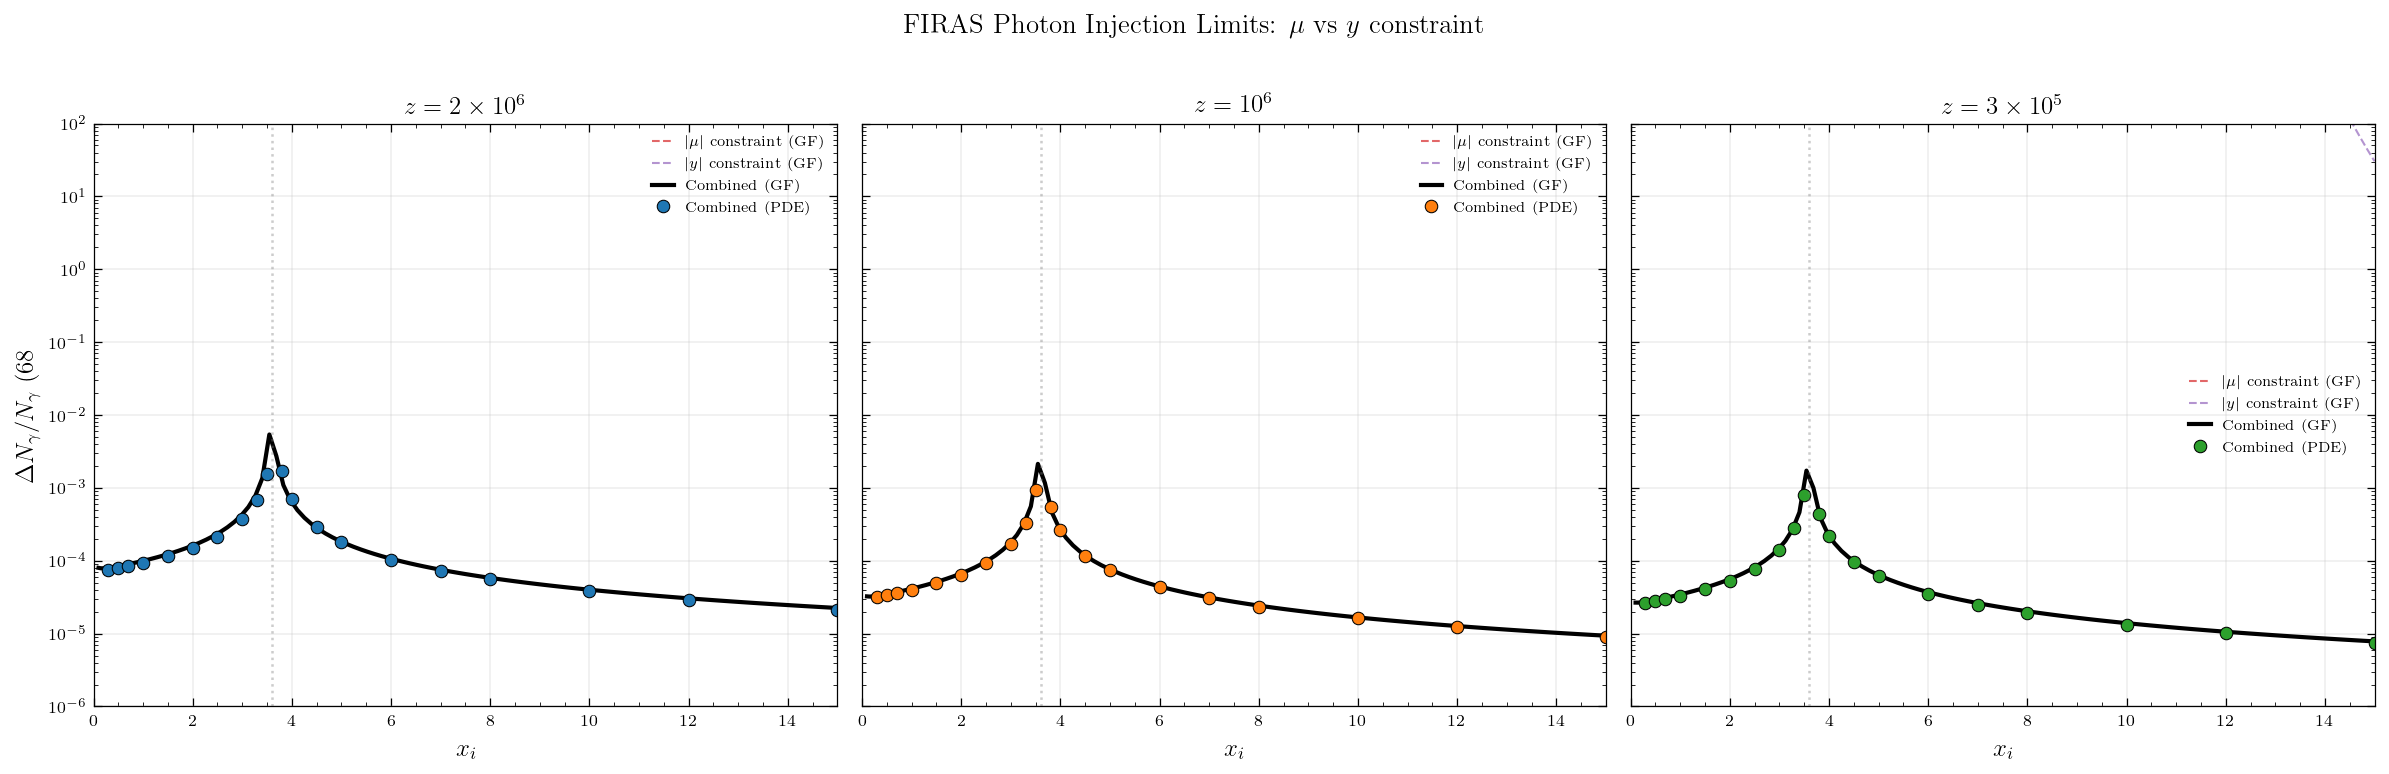

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, z_h, label, color in zip(axes, z_values, z_labels, z_colors):
    gf = gf_results[z_h]
    pde = pde_results[z_h]
    
    # GF curves
    ax.semilogy(gf['x_i'], gf['dn_max_mu'], '--', color='C3', lw=1, alpha=0.7,
                label=r'$|\mu|$ constraint (GF)')
    ax.semilogy(gf['x_i'], gf['dn_max_y'], '--', color='C4', lw=1, alpha=0.7,
                label=r'$|y|$ constraint (GF)')
    ax.semilogy(gf['x_i'], gf['dn_max'], '-', color='k', lw=2,
                label='Combined (GF)')
    
    # PDE
    valid = np.isfinite(pde['dn_max']) & (pde['dn_max'] < 1e10)
    ax.semilogy(pde['x_i'][valid], pde['dn_max'][valid], 'o', color=color,
                ms=6, markeredgecolor='k', markeredgewidth=0.5,
                label='Combined (PDE)')
    
    ax.axvline(X_BALANCED, color='gray', ls=':', alpha=0.4)
    ax.set_xlabel(r'$x_i$', fontsize=12)
    ax.set_title(label, fontsize=12)
    ax.set_xlim(0, 15)
    ax.set_ylim(1e-6, 1e2)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7)

axes[0].set_ylabel(r'$\Delta N_\gamma / N_\gamma$ (68% CL)', fontsize=12)

fig.suptitle('FIRAS Photon Injection Limits: $\\mu$ vs $y$ constraint', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/firas_photon_mu_vs_y_constraint.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Raw Spectral Comparison: PDE vs Green's Function

The $\mu$/$y$ decomposition can show large discrepancies due to cross-talk between
$M(x)$ and $Y_\mathrm{SZ}(x)$ in the least-squares projection, even when the underlying
spectra agree well. Here we compare the **raw $\Delta n(x)$ spectra** directly,
bypassing the decomposition entirely.

We select 3 representative injection frequencies ($x_i = 1, 3.8, 8$) spanning the
sub-balanced, near-balanced, and super-balanced regimes, and compare the full PDE output
against the analytical Green's function at each of the 3 injection redshifts.

Running PDE: x_i=1.0, z=2e+06 ... done (mu=-4.81e-06, y=-8.27e-10)
Running PDE: x_i=3.8, z=2e+06 ... done (mu=2.64e-07, y=2.51e-11)
Running PDE: x_i=8.0, z=2e+06 ... done (mu=8.07e-06, y=8.63e-10)
Running PDE: x_i=1.0, z=1e+06 ... done (mu=-1.13e-05, y=-1.88e-09)
Running PDE: x_i=3.8, z=1e+06 ... done (mu=8.23e-07, y=8.55e-11)
Running PDE: x_i=8.0, z=1e+06 ... done (mu=1.91e-05, y=2.16e-09)
Running PDE: x_i=1.0, z=3e+05 ... done (mu=-1.37e-05, y=-6.19e-09)
Running PDE: x_i=3.8, z=3e+05 ... done (mu=1.03e-06, y=9.78e-11)
Running PDE: x_i=8.0, z=3e+05 ... done (mu=2.33e-05, y=1.04e-08)

Total time: 1476s


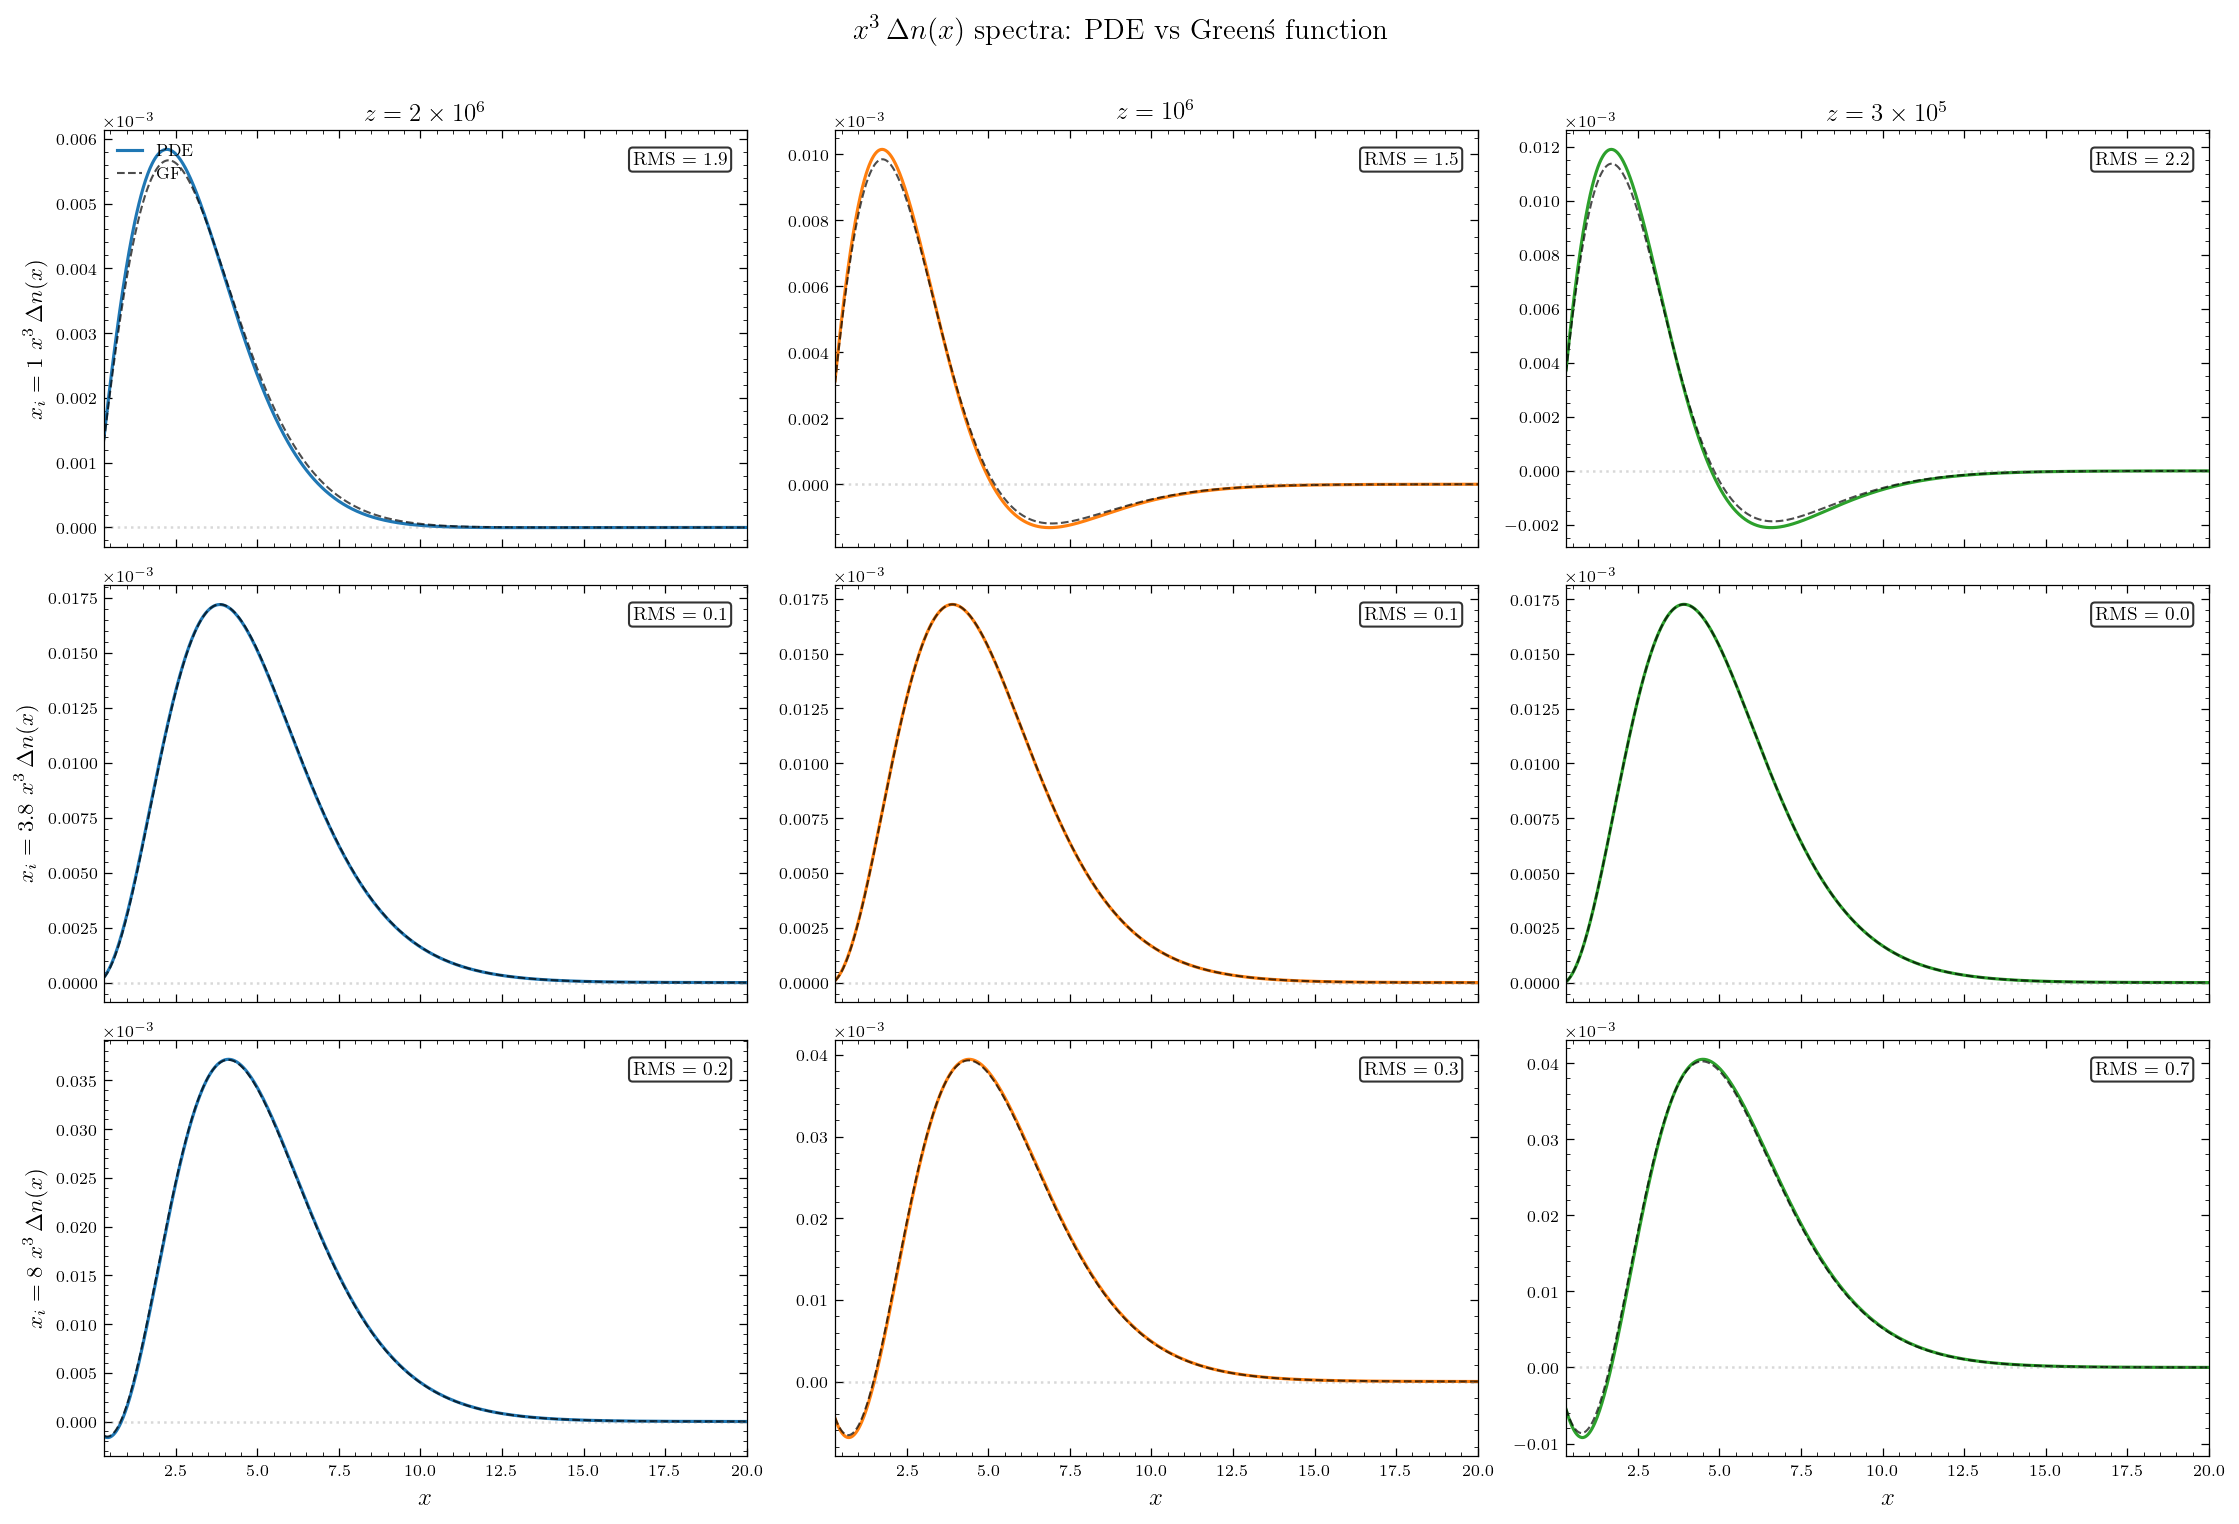

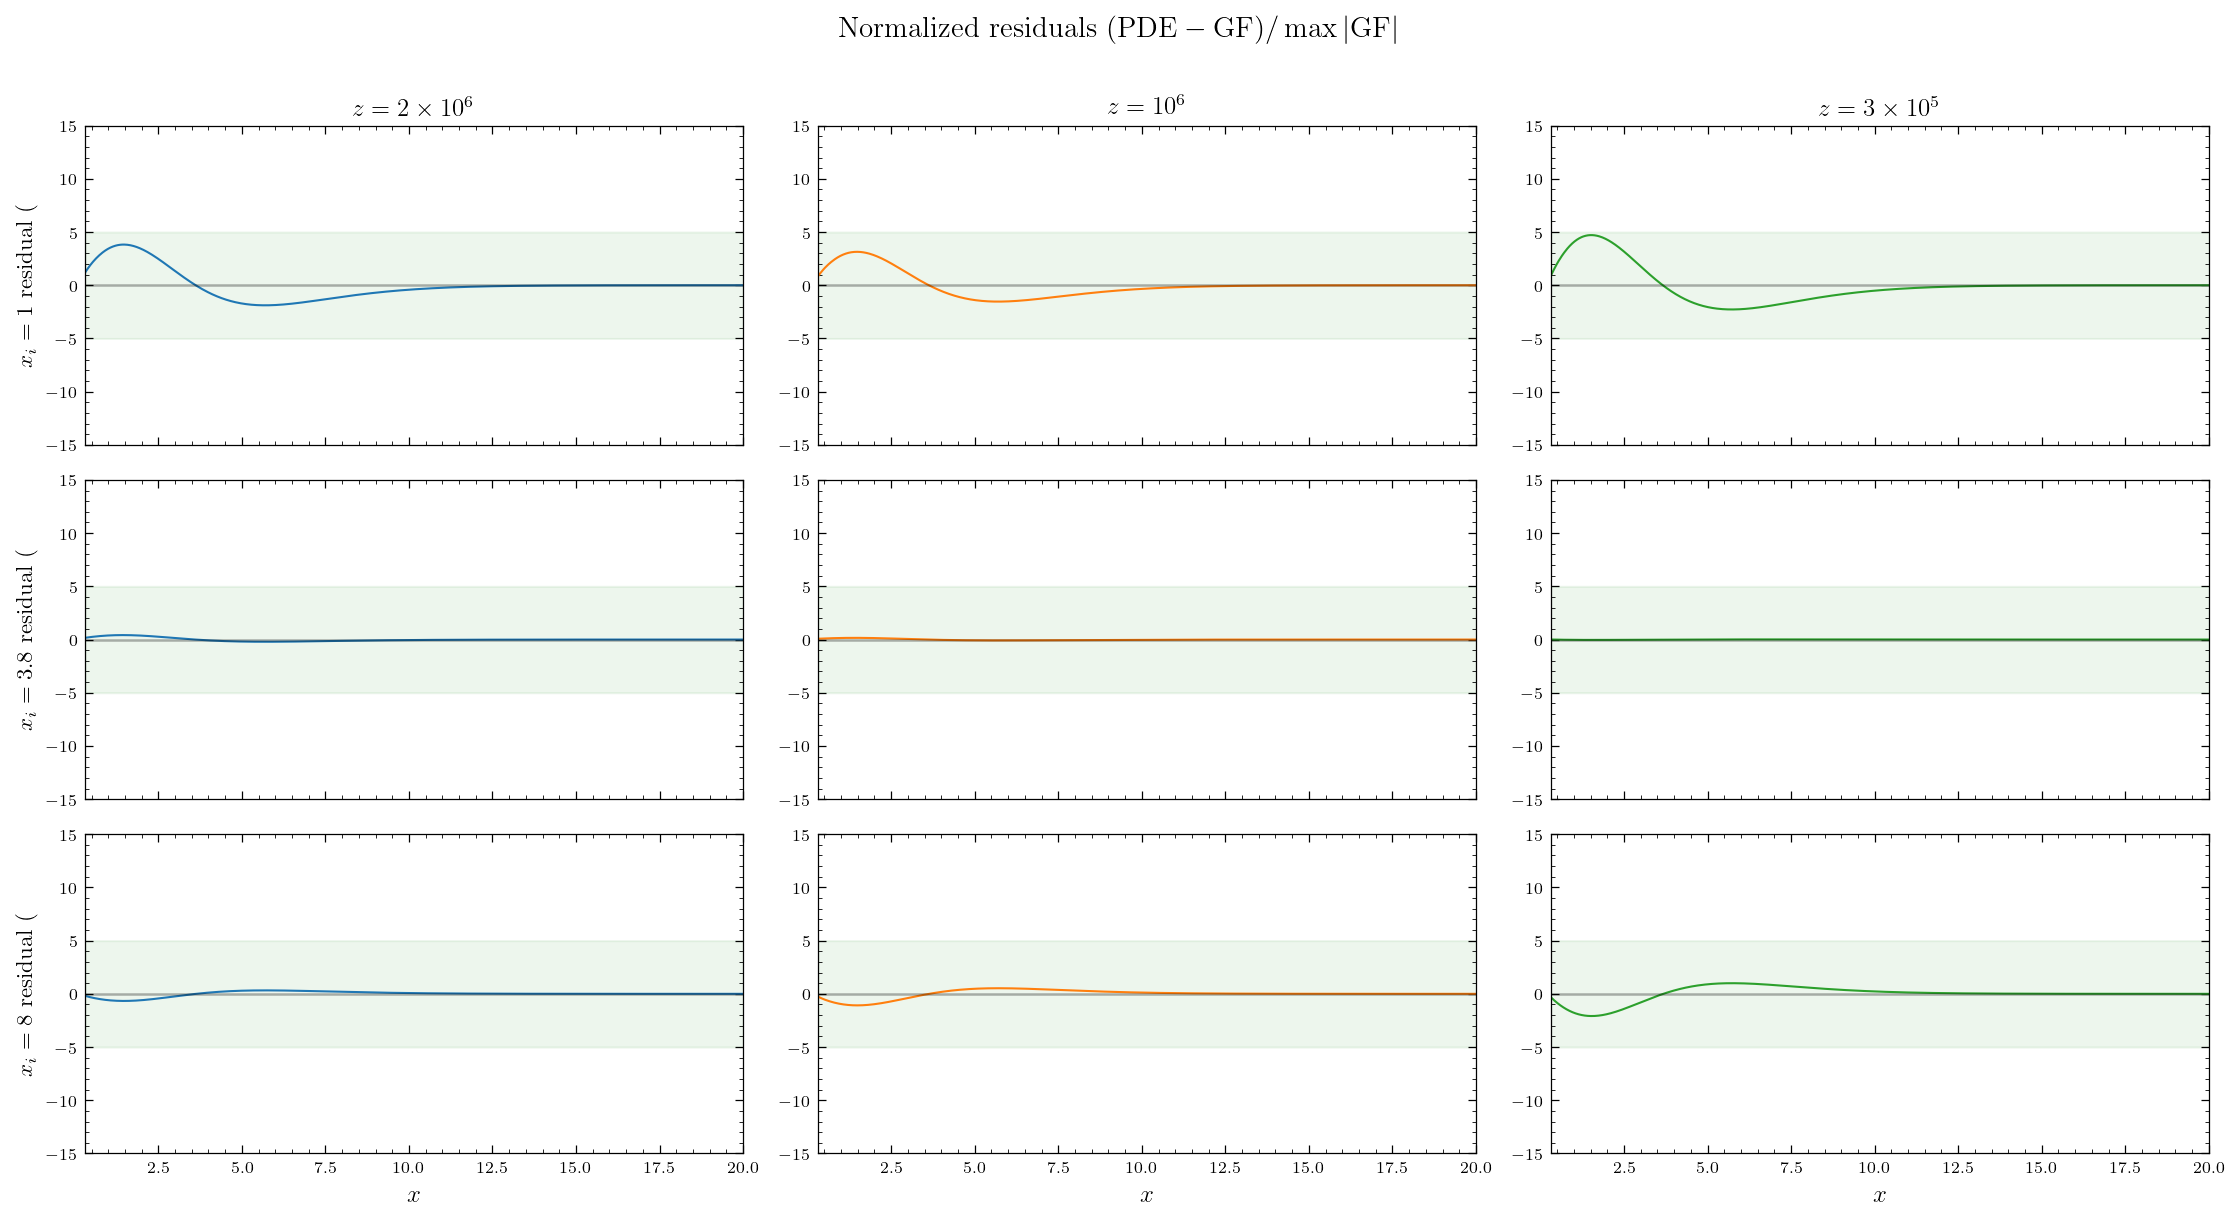


Raw spectral RMS (%) — PDE vs GF:
   x_i  z=2e+06  z=1e+06  z=3e+05
----------------------------------------
   1.0       1.6       1.1       1.6  
   3.8       0.1       0.0       0.0  
   8.0       0.2       0.3       0.7  


In [9]:
# Representative injection frequencies: sub-balanced, near-balanced, super-balanced
x_i_raw = [1.0, 3.8, 8.0]
x_i_labels = [r'$x_i = 1$', r'$x_i = 3.8$', r'$x_i = 8$']

# Run 9 PDE cases (3 x_i × 3 z_h) and store spectra
raw_spectra = {}
t0 = time.time()

for z_h in z_values:
    for x_i in x_i_raw:
        key = (x_i, z_h)
        print(f'Running PDE: x_i={x_i}, z={z_h:.0e} ...', end='', flush=True)
        try:
            x_pde, dn_pde, mu, y = run_pde_photon(x_i, z_h, delta_n_over_n=dn_over_n)
            # GF spectrum on same grid (per unit DN/N, then scale)
            sigma_x = default_sigma_x(x_i)
            dn_gf = greens_function_photon(x_pde, x_i, z_h, sigma_x=sigma_x) * dn_over_n
            raw_spectra[key] = {'x': x_pde, 'dn_pde': dn_pde, 'dn_gf': dn_gf,
                                'mu': mu, 'y': y}
            print(f' done (mu={mu:.2e}, y={y:.2e})')
        except Exception as e:
            print(f' FAILED: {e}')

print(f'\nTotal time: {time.time() - t0:.0f}s')

# --- Plot: 3×3 grid, rows = x_i, columns = z_h ---
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)

for row, (x_i, xi_label) in enumerate(zip(x_i_raw, x_i_labels)):
    for col, (z_h, z_label, color) in enumerate(zip(z_values, z_labels, z_colors)):
        ax = axes[row, col]
        key = (x_i, z_h)
        if key not in raw_spectra:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            continue

        d = raw_spectra[key]
        x = d['x']
        mask = (x > 0.3) & (x < 25)
        x_m, pde_m, gf_m = x[mask], d['dn_pde'][mask], d['dn_gf'][mask]

        ax.plot(x_m, x_m**3 * pde_m, '-', color=color, lw=1.5, label='PDE')
        ax.plot(x_m, x_m**3 * gf_m, '--', color='k', lw=1, alpha=0.7, label='GF')
        ax.axhline(0, color='gray', ls=':', alpha=0.3)

        # RMS residual (where GF is non-negligible)
        gf_scale = np.max(np.abs(x_m**3 * gf_m))
        if gf_scale > 0:
            resid = (x_m**3 * pde_m - x_m**3 * gf_m) / gf_scale
            rms = np.sqrt(np.mean(resid**2)) * 100
            ax.text(0.97, 0.95, f'RMS = {rms:.1f}%', transform=ax.transAxes,
                    ha='right', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

        if row == 0:
            ax.set_title(z_label, fontsize=12)
        if col == 0:
            ax.set_ylabel(xi_label + r'  $x^3 \, \Delta n(x)$', fontsize=11)
        if row == 2:
            ax.set_xlabel(r'$x$', fontsize=12)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper left')

        ax.set_xlim(0.3, 20)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-3, -3))

fig.suptitle(r'$x^3 \, \Delta n(x)$ spectra: PDE vs Green\'s function', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/firas_photon_raw_spectra.pdf', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot: Normalized residuals ---
fig, axes = plt.subplots(3, 3, figsize=(15, 8), sharex=True)

for row, (x_i, xi_label) in enumerate(zip(x_i_raw, x_i_labels)):
    for col, (z_h, z_label, color) in enumerate(zip(z_values, z_labels, z_colors)):
        ax = axes[row, col]
        key = (x_i, z_h)
        if key not in raw_spectra:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            continue

        d = raw_spectra[key]
        x = d['x']
        mask = (x > 0.3) & (x < 25)
        x_m, pde_m, gf_m = x[mask], d['dn_pde'][mask], d['dn_gf'][mask]

        gf_scale = np.max(np.abs(x_m**3 * gf_m))
        if gf_scale > 0:
            resid_pct = (x_m**3 * pde_m - x_m**3 * gf_m) / gf_scale * 100
            ax.plot(x_m, resid_pct, '-', color=color, lw=1)
            ax.axhline(0, color='k', ls='-', alpha=0.3)
            ax.fill_between(x_m, -5, 5, color='green', alpha=0.07)

        if row == 0:
            ax.set_title(z_label, fontsize=12)
        if col == 0:
            ax.set_ylabel(xi_label + r'  residual (%)', fontsize=11)
        if row == 2:
            ax.set_xlabel(r'$x$', fontsize=12)

        ax.set_xlim(0.3, 20)
        ax.set_ylim(-15, 15)

fig.suptitle(r'Normalized residuals $({\rm PDE} - {\rm GF}) / \max|{\rm GF}|$', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/firas_photon_residuals.pdf', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\nRaw spectral RMS (%) — PDE vs GF:')
print(f'{"x_i":>6s}  ' + '  '.join(f'z={z:.0e}' for z in z_values))
print('-' * 40)
for x_i in x_i_raw:
    row_str = f'{x_i:6.1f}  '
    for z_h in z_values:
        key = (x_i, z_h)
        if key in raw_spectra:
            d = raw_spectra[key]
            x = d['x']
            mask = (x > 0.3) & (x < 25)
            gf_scale = np.max(np.abs(x_m**3 * d['dn_gf'][mask]))
            if gf_scale > 0:
                rms = np.sqrt(np.mean(((x_m**3 * d['dn_pde'][mask] - x_m**3 * d['dn_gf'][mask]) / gf_scale)**2)) * 100
                row_str += f'{rms:8.1f}  '
            else:
                row_str += '     ---  '
        else:
            row_str += '     N/A  '
    print(row_str)